# Customer Churn Prediction

**Predicting bank customer churn using Logistic Regression, Random Forest, and Gradient Boosting**

---

| Detail | Value |
|--------|-------|
| **Dataset** | Bank Customer Churn (Kaggle) |
| **Techniques** | EDA, Feature Engineering, Logistic Regression, Random Forest, Cross-Validation |
| **Author** | Ahmed Alnahrawy |



## 1. Data Loading & Initial Exploration

Load the dataset and perform initial inspection of features, data types, and missing values.


In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import StandardScaler

In [2]:
df=pd.read_csv('../data/Churn_Modelling.csv')
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,1,1,1,79084.10,0



## 2. Data Preprocessing

Clean and prepare features — drop irrelevant columns, encode categoricals, and scale numerics.


In [3]:
df.drop(columns=['RowNumber', 'CustomerId','Surname'],axis=1,inplace=True)

## Exploratory Data Analysis
Let's explore the relationships between various features and customer churn (Exited) to get better insights.

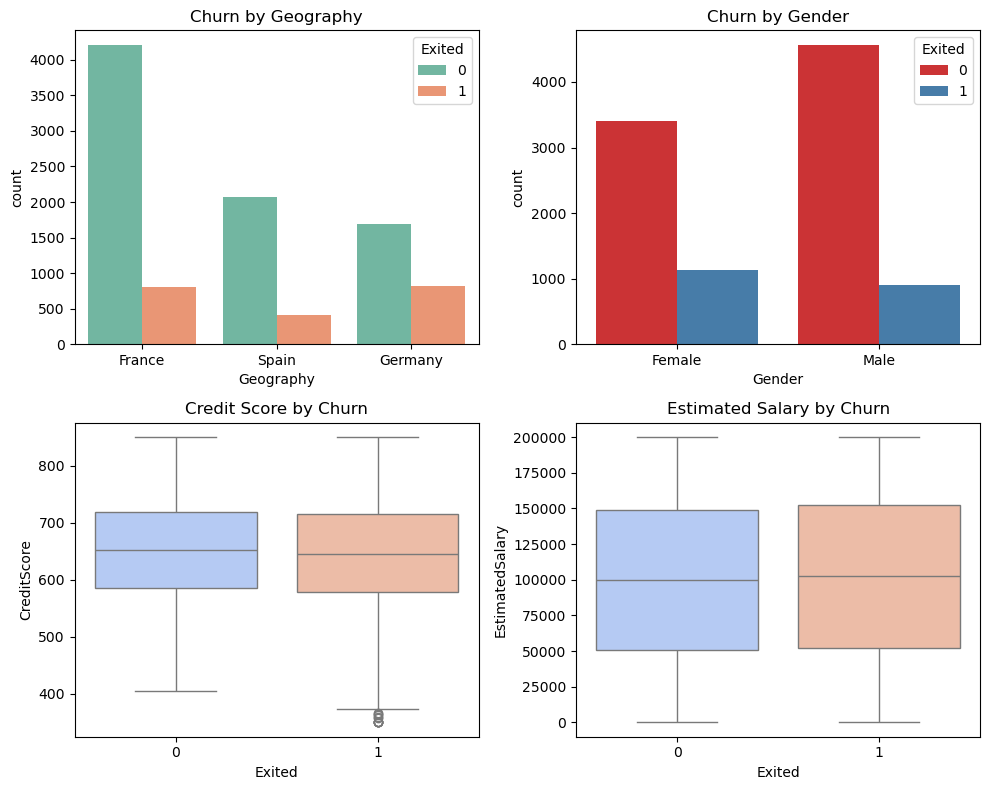

In [4]:
# 1. Demographics & Financials vs Churn
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

sns.countplot(x='Geography', hue='Exited', data=df, palette='Set2', ax=axes[0, 0])
axes[0, 0].set_title('Churn by Geography')

sns.countplot(x='Gender', hue='Exited', data=df, palette='Set1', ax=axes[0, 1])
axes[0, 1].set_title('Churn by Gender')

sns.boxplot(x='Exited', y='CreditScore', hue='Exited', data=df, palette='coolwarm', legend=False, ax=axes[1, 0])
axes[1, 0].set_title('Credit Score by Churn')

sns.boxplot(x='Exited', y='EstimatedSalary', hue='Exited', data=df, palette='coolwarm', legend=False, ax=axes[1, 1])
axes[1, 1].set_title('Estimated Salary by Churn')

plt.tight_layout()
plt.show()

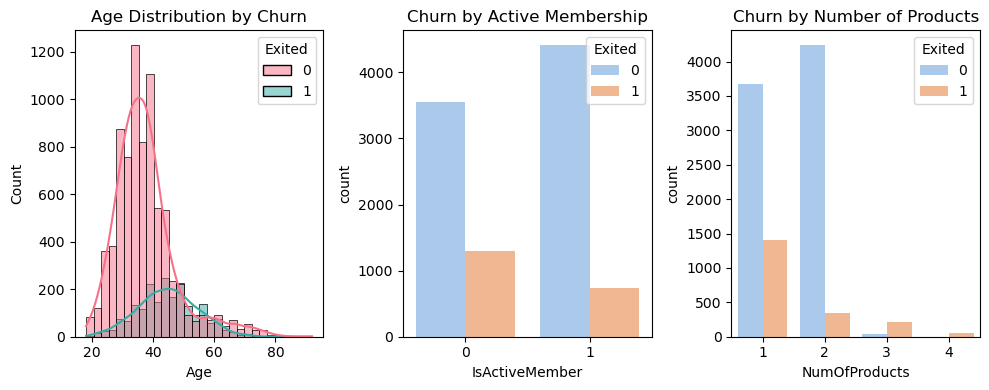

In [5]:
# 2. Age Distribution & Account Details vs Churn
fig, axes = plt.subplots(1, 3, figsize=(10, 4))

sns.histplot(data=df, x='Age', hue='Exited', kde=True, bins=30, palette='husl', ax=axes[0])
axes[0].set_title('Age Distribution by Churn')

sns.countplot(x='IsActiveMember', hue='Exited', data=df, palette='pastel', ax=axes[1])
axes[1].set_title('Churn by Active Membership')

sns.countplot(x='NumOfProducts', hue='Exited', data=df, palette='pastel', ax=axes[2])
axes[2].set_title('Churn by Number of Products')

plt.tight_layout()
plt.show()


## 3. Exploratory Data Analysis

Visualize feature distributions and their relationship with the target variable (Exited).


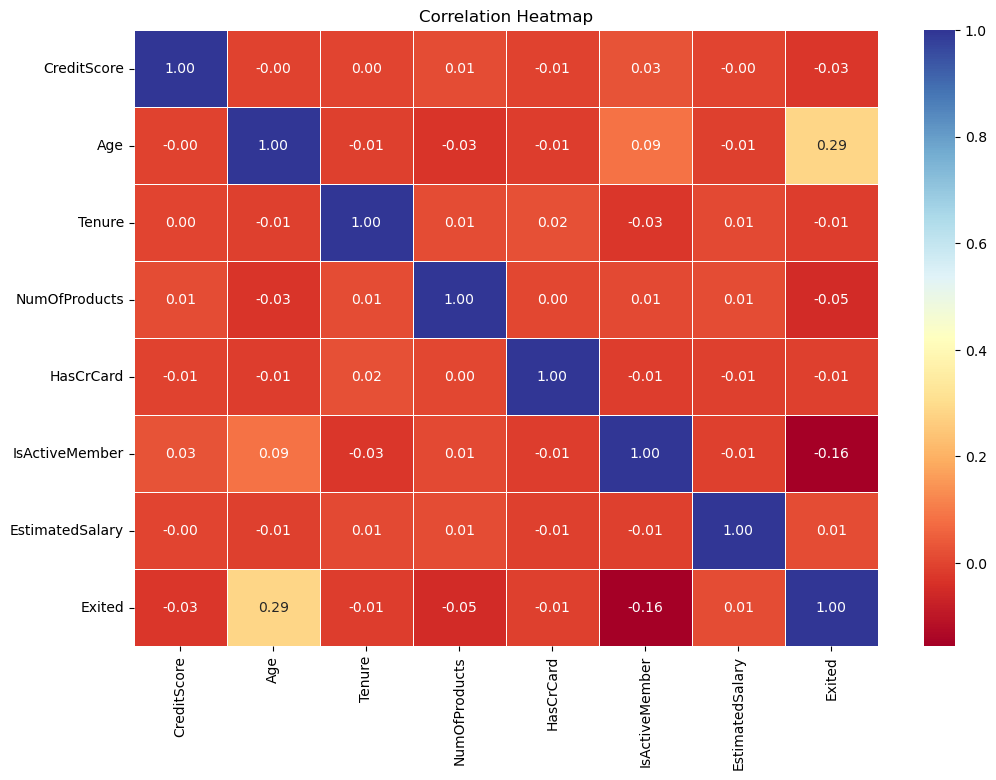

In [6]:
# 3. Correlation Heatmap
plt.figure(figsize=(12, 8))
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, cmap='RdYlBu', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

In [7]:
df['Gender'] = [0 if g == 'Male' else 1 for g in df['Gender']]
df=pd.get_dummies(df,columns=['Geography'] , drop_first=True , dtype=int)
df.head()

,CreditScore,Gender,Age,Tenure,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain
0,619,1,42,2,1,1,1,101348.88,1,0,0
1,608,1,41,1,1,0,1,112542.58,0,0,1
2,502,1,42,8,3,1,0,113931.57,1,0,0
3,699,1,39,1,2,0,0,93826.63,0,0,0
4,850,1,43,2,1,1,1,79084.10,0,0,1



## 4. Model Training & Evaluation

Train classification models and evaluate using accuracy, confusion matrix, and cross-validation.


In [8]:
X = df.drop(columns=['Exited'])
y = df['Exited']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

model = LogisticRegression(random_state=42)

In [9]:
cv_scores = cross_val_score(model, X_scaled, y, cv=5)

Test Accuracy: 0.816
Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.96      0.89      1607
           1       0.59      0.21      0.31       393

    accuracy                           0.82      2000
   macro avg       0.71      0.59      0.60      2000
weighted avg       0.79      0.82      0.78      2000



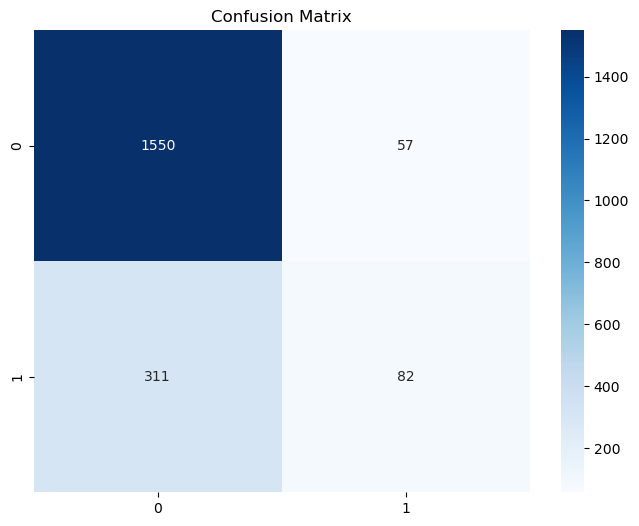

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print(f'Test Accuracy: {accuracy_score(y_test, y_pred)}')
print('Classification Report:')
print(classification_report(y_test, y_pred))

# Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.show()


---

## Summary

This notebook demonstrated eda, feature engineering, logistic regression, random forest, cross-validation techniques applied to the Bank Customer Churn (Kaggle).

**Author:** Ahmed Alnahrawy | [GitHub](https://github.com/Ahmed-Na7rawy)
